# OMB Analysis

In [35]:
DATA_DIR = 'data'\n%config InlineBackend.figure_format = 'svg'

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from openMWR.models import Model
from openMWR.omb import Omb_Analysis, get_input_noise



In [36]:
site = 'munich_G5'

data_source = 'radiosonde'

model = Model.load('NN_opt', site=site, data_dir=DATA_DIR)

input_noise = get_input_noise(model)

In [37]:
station_ids_for_analysis = ['03715']

omb = Omb_Analysis(site, DATA_DIR, data_source=data_source, station_ids_for_analysis=station_ids_for_analysis, load_existing_analysis_dataset=True, file_extension='') #'R17'
omb.diff

<xarray.DataArray 'TB' (time: 770, frq: 14)> Size: 86kB
array([[-1.40297411, -1.26841401, -1.00572544, ...,  0.93969751,
         1.066543  ,  1.09720991],
       [-2.58776186, -2.37139069, -2.01889836, ...,  0.90047798,
         1.04439825,  1.07300073],
       [ 0.39260703,  0.67978445,  1.03742362, ..., -0.23038844,
        -0.22769913, -0.23773495],
       ...,
       [-1.37367536, -0.92333656, -0.9081708 , ...,  0.33742529,
         0.38558368,  0.32665472],
       [-1.31882046, -0.74580405, -0.80185115, ...,  0.90980798,
         1.08574595,  1.10787999],
       [-1.84070434, -1.36453684, -1.31819138, ...,  0.88988553,
         1.08184554,  1.1346612 ]], shape=(770, 14))
Coordinates:
  * time     (time) datetime64[ns] 6kB 2024-11-01T10:45:00 ... 2026-01-19T22:...
  * frq      (frq) float64 112B 22.24 23.04 23.84 25.44 ... 56.66 57.3 58.0
    synop    (time) datetime64[ns] 6kB 2024-11-01T12:00:00 ... 2026-01-20

In [38]:
omb.filter_lwp(lwp_threshold=2)

omb.diff

<xarray.DataArray 'TB' (time: 344, frq: 14)> Size: 39kB
array([[-1.40297411, -1.26841401, -1.00572544, ...,  0.93969751,
         1.066543  ,  1.09720991],
       [-2.58776186, -2.37139069, -2.01889836, ...,  0.90047798,
         1.04439825,  1.07300073],
       [-0.54014704, -0.19074624, -0.45763188, ...,  0.27013049,
         0.34309084,  0.25480603],
       ...,
       [-1.89182856, -1.39838717, -1.25472159, ...,  1.03117385,
         1.25703493,  1.28493482],
       [-1.31882046, -0.74580405, -0.80185115, ...,  0.90980798,
         1.08574595,  1.10787999],
       [-1.84070434, -1.36453684, -1.31819138, ...,  0.88988553,
         1.08184554,  1.1346612 ]], shape=(344, 14))
Coordinates:
  * time     (time) datetime64[ns] 3kB 2024-11-01T10:45:00 ... 2026-01-19T22:...
  * frq      (frq) float64 112B 22.24 23.04 23.84 25.44 ... 56.66 57.3 58.0
    synop    (time) datetime64[ns] 3kB 2024-11-01T12:00:00 ... 2026-01-20

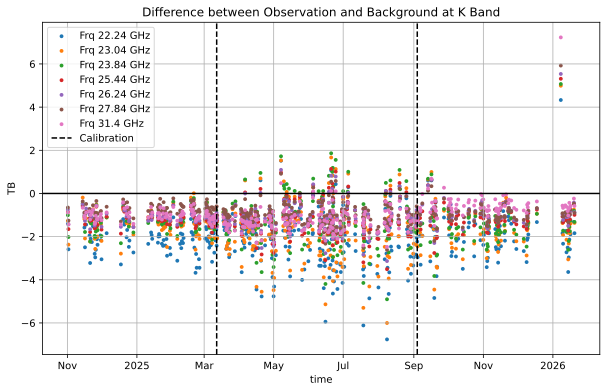

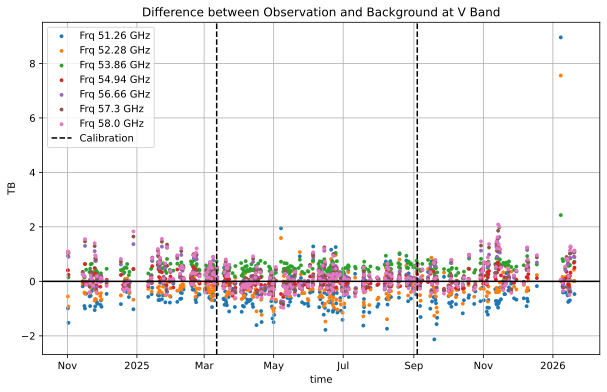

In [39]:
plt.figure(figsize=(10, 6))
for i in range(7):
    omb.diff.isel(frq=i).plot.scatter(x='time', y=None, edgecolors='none', s=15, label=f'Frq {omb.diff.frq.isel(frq=i).values} GHz');
plt.axvline(pd.Timestamp('2025-03-12'), color='k', linestyle='--', label='Calibration')
plt.axvline(pd.Timestamp('2025-09-04'), color='k', linestyle='--')
plt.axhline(0, color='k')
plt.title(f'Difference between Observation and Background at K Band')
plt.grid()
plt.legend()
plt.show()
plt.figure(figsize=(10, 6))
for i in range(7,14):
    omb.diff.isel(frq=i).plot.scatter(x='time', y=None, edgecolors='none', s=15, label=f'Frq {omb.diff.frq.isel(frq=i).values} GHz');
plt.axvline(pd.Timestamp('2025-03-12'), color='k', linestyle='--', label='Calibration')
plt.axvline(pd.Timestamp('2025-09-04'), color='k', linestyle='--')
plt.title(f'Difference between Observation and Background at V Band')
plt.axhline(0, color='k')
plt.grid()
plt.legend()
plt.show()

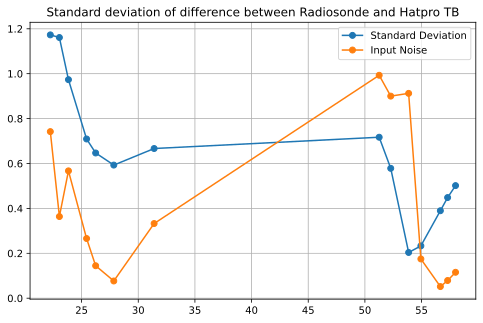

In [40]:
std = omb.std_diff

plt.figure(figsize=(8, 5))
plt.plot(std.frq, std, marker='o', linestyle='-', label='Standard Deviation');
plt.plot(input_noise.frq, input_noise.TB, marker='o', linestyle='-', label='Input Noise');
plt.title('Standard deviation of difference between Radiosonde and Hatpro TB');
plt.grid();
plt.legend();

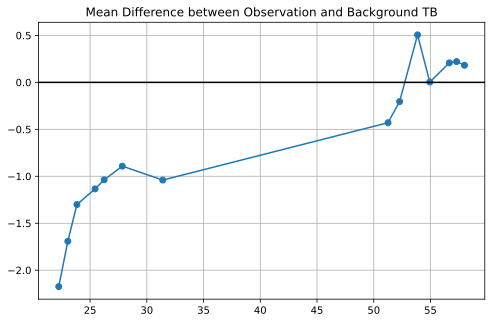

In [41]:
mean = omb.mean_diff

plt.figure(figsize=(8, 5))
plt.plot(mean.frq, mean, marker='o', linestyle='-');
plt.title('Mean Difference between Observation and Background TB')
plt.axhline(0, color='k')
plt.grid();

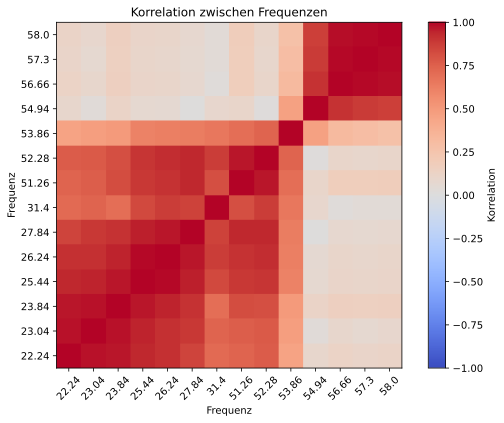

In [42]:
corr_matrix = xr.corr(omb.diff, omb.diff.rename(frq = 'frq2'), dim="time")

n_freq = len(omb.diff.frq)

plt.figure(figsize=(8, 6))
im = plt.imshow(np.abs(corr_matrix), 
                origin='lower', 
                cmap='coolwarm', 
                vmin=-1, vmax=1,
                )

plt.colorbar(im, label="Korrelation")
plt.xticks(ticks=np.arange(n_freq), labels=corr_matrix.frq.values, rotation=45)
plt.yticks(ticks=np.arange(n_freq), labels=corr_matrix.frq2.values)
plt.title("Korrelation zwischen Frequenzen")
plt.xlabel("Frequenz")
plt.ylabel("Frequenz")
plt.tight_layout()

In [43]:
resid_diff, resid_std = omb.remove_explained_variance()

resid_std

<xarray.DataArray (frq: 14)> Size: 112B
array([0.33823873, 0.2018027 , 0.18984346, 0.09704575, 0.13247507,
       0.27405771, 0.53062621, 0.26204186, 0.24931903, 0.50929831,
       0.41307335, 0.11798895, 0.08452118, 0.13577296])
Coordinates:
  * frq      (frq) float64 112B 22.24 23.04 23.84 25.44 ... 56.66 57.3 58.0

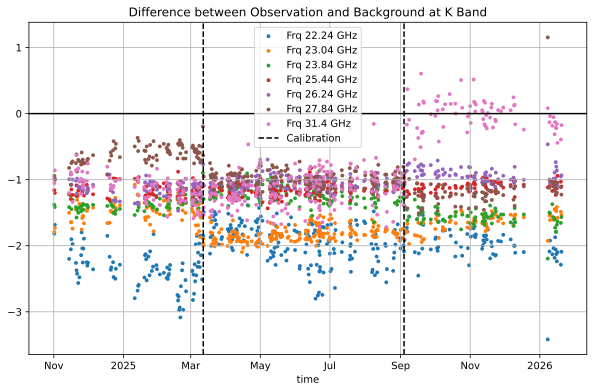

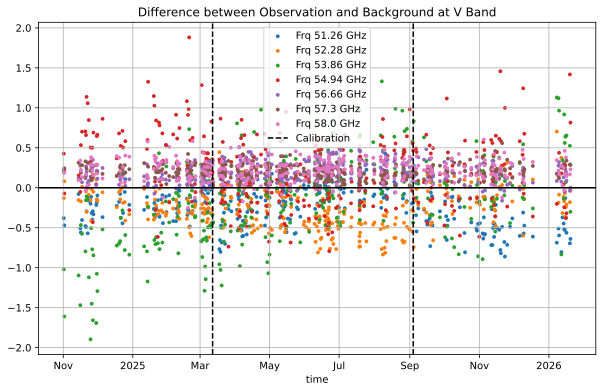

In [44]:
plt.figure(figsize=(10, 6))
for i in range(7):
    (resid_diff+mean).isel(frq=i).plot.scatter(x='time', y=None, edgecolors='none', s=15, label=f'Frq {omb.diff.frq.isel(frq=i).values} GHz');
plt.axvline(pd.Timestamp('2025-03-12'), color='k', linestyle='--', label='Calibration')
plt.axvline(pd.Timestamp('2025-09-04'), color='k', linestyle='--')
plt.axhline(0, color='k')
plt.title(f'Difference between Observation and Background at K Band')
plt.grid()
plt.legend()
plt.show()
plt.figure(figsize=(10, 6))
for i in range(7,14):
    (resid_diff+mean).isel(frq=i).plot.scatter(x='time', y=None, edgecolors='none', s=15, label=f'Frq {omb.diff.frq.isel(frq=i).values} GHz');
plt.axvline(pd.Timestamp('2025-03-12'), color='k', linestyle='--', label='Calibration')
plt.axvline(pd.Timestamp('2025-09-04'), color='k', linestyle='--')
plt.title(f'Difference between Observation and Background at V Band')
plt.axhline(0, color='k')
plt.grid()
plt.legend()
plt.show()

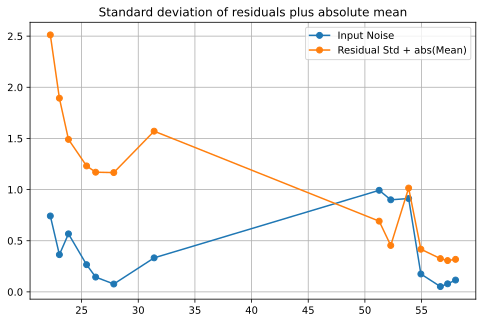

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(input_noise.frq, input_noise.TB, marker='o', linestyle='-', label='Input Noise');
plt.plot(resid_std.frq, resid_std + np.abs(mean), marker='o', linestyle='-', label='Residual Std + abs(Mean)');
plt.legend()
plt.title('Standard deviation of residuals plus absolute mean')
plt.grid();